[OK] correctness passed


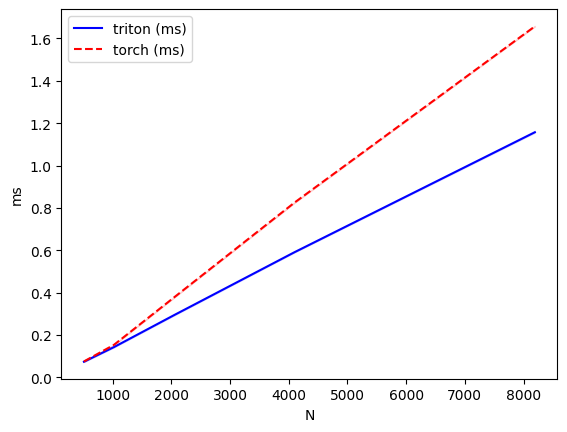

layernorm_forward_M4096:
        N  triton (ms)  torch (ms)
0   512.0     0.073568    0.075072
1  1024.0     0.142912    0.153600
2  2048.0     0.293792    0.377568
3  4096.0     0.590400    0.824416
4  8192.0     1.157120    1.656864


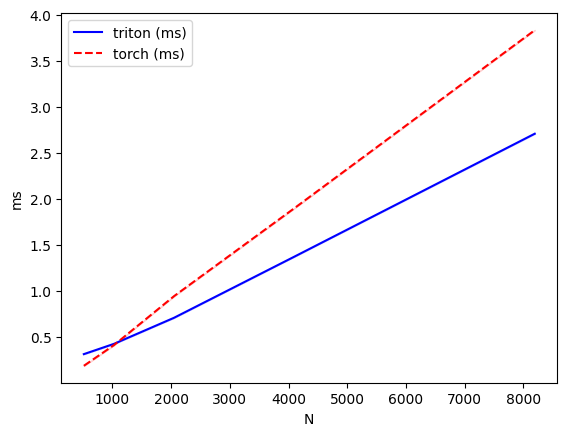

layernorm_backward_M4096:
        N  triton (ms)  torch (ms)
0   512.0     0.311296    0.184320
1  1024.0     0.422816    0.408832
2  2048.0     0.706496    0.941376
3  4096.0     1.370688    1.897104
4  8192.0     2.708048    3.833968


In [1]:
import torch
import triton
import triton.language as tl


def _next_pow2(n: int) -> int:
    return max(16, 1 << (n - 1).bit_length())


# =========================== FORWARD KERNEL ===========================

@triton.autotune(
    configs=[
        triton.Config({}, num_warps=2),
        triton.Config({}, num_warps=4),
        triton.Config({}, num_warps=8),
        triton.Config({}, num_warps=16),
    ],
    key=["N"],
)
@triton.jit
def _layernorm_forward_kernel(
    x_ptr, y_ptr, w_ptr, b_ptr,
    mean_ptr, rstd_ptr,
    x_stride, y_stride,
    N, eps,
    BLOCK_N: tl.constexpr,
):
    row = tl.program_id(axis=0)
    cols = tl.arange(0, BLOCK_N)
    mask = cols < N

    x = tl.load(x_ptr + row * x_stride + cols, mask=mask, other=0.0).to(tl.float32)

    mean = tl.sum(x, axis=0) / N
    x_centered = tl.where(mask, x - mean, 0.0)
    var = tl.sum(x_centered * x_centered, axis=0) / N
    rstd = 1.0 / tl.sqrt(var + eps)

    tl.store(mean_ptr + row, mean)
    tl.store(rstd_ptr + row, rstd)

    w = tl.load(w_ptr + cols, mask=mask, other=0.0).to(tl.float32)
    b = tl.load(b_ptr + cols, mask=mask, other=0.0).to(tl.float32)

    y = x_centered * rstd * w + b
    tl.store(y_ptr + row * y_stride + cols, y, mask=mask)


# =========================== BACKWARD KERNEL: DX ===========================

@triton.autotune(
    configs=[
        triton.Config({}, num_warps=2),
        triton.Config({}, num_warps=4),
        triton.Config({}, num_warps=8),
        triton.Config({}, num_warps=16),
    ],
    key=["N"],
)
@triton.jit
def _layernorm_backward_dx_kernel(
    x_ptr, w_ptr, dy_ptr, mean_ptr, rstd_ptr,
    dx_ptr,
    x_stride, dy_stride, dx_stride,
    N,
    BLOCK_N: tl.constexpr,
):
    row = tl.program_id(axis=0)
    cols = tl.arange(0, BLOCK_N)
    mask = cols < N

    x = tl.load(x_ptr + row * x_stride + cols, mask=mask, other=0.0).to(tl.float32)
    dy = tl.load(dy_ptr + row * dy_stride + cols, mask=mask, other=0.0).to(tl.float32)
    w = tl.load(w_ptr + cols, mask=mask, other=0.0).to(tl.float32)
    mean = tl.load(mean_ptr + row).to(tl.float32)
    rstd = tl.load(rstd_ptr + row).to(tl.float32)

    xhat = tl.where(mask, (x - mean) * rstd, 0.0)
    dxhat = dy * w

    c1 = tl.sum(dxhat, axis=0) / N
    c2 = tl.sum(dxhat * xhat, axis=0) / N

    dx = rstd * (dxhat - c1 - xhat * c2)
    tl.store(dx_ptr + row * dx_stride + cols, dx, mask=mask)


# =========================== BACKWARD KERNEL: DW / DB ===========================

@triton.autotune(
    configs=[
        triton.Config({"BLOCK_M": 32, "BLOCK_N": 64}, num_warps=4),
        triton.Config({"BLOCK_M": 64, "BLOCK_N": 64}, num_warps=4),
        triton.Config({"BLOCK_M": 64, "BLOCK_N": 128}, num_warps=8),
        triton.Config({"BLOCK_M": 128, "BLOCK_N": 128}, num_warps=8),
    ],
    key=["M", "N"],
)
@triton.jit
def _layernorm_backward_dwdb_kernel(
    x_ptr, dy_ptr, mean_ptr, rstd_ptr,
    dw_ptr, db_ptr,
    x_stride, dy_stride,
    M, N,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
):
    pid = tl.program_id(axis=0)
    cols = pid * BLOCK_N + tl.arange(0, BLOCK_N)
    mask_n = cols < N

    dw_acc = tl.zeros((BLOCK_N,), dtype=tl.float32)
    db_acc = tl.zeros((BLOCK_N,), dtype=tl.float32)

    for row_start in range(0, M, BLOCK_M):
        rows = row_start + tl.arange(0, BLOCK_M)
        mask_m = rows < M
        m2d = mask_m[:, None] & mask_n[None, :]

        x = tl.load(
            x_ptr + rows[:, None] * x_stride + cols[None, :],
            mask=m2d,
            other=0.0,
        ).to(tl.float32)

        dy = tl.load(
            dy_ptr + rows[:, None] * dy_stride + cols[None, :],
            mask=m2d,
            other=0.0,
        ).to(tl.float32)

        mean = tl.load(mean_ptr + rows, mask=mask_m, other=0.0).to(tl.float32)
        rstd = tl.load(rstd_ptr + rows, mask=mask_m, other=0.0).to(tl.float32)

        xhat = (x - mean[:, None]) * rstd[:, None]

        dw_acc += tl.sum(dy * xhat, axis=0)
        db_acc += tl.sum(dy, axis=0)

    tl.store(dw_ptr + cols, dw_acc, mask=mask_n)
    tl.store(db_ptr + cols, db_acc, mask=mask_n)


# =========================== PYTHON IMPLEMENTATION ===========================

def _forward_impl(x: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor, eps: float):
    x2d = x.contiguous().view(-1, x.shape[-1])
    weight = weight.contiguous()
    bias = bias.contiguous()

    M, N = x2d.shape
    BLOCK_N = _next_pow2(N)

    y = torch.empty_like(x2d)
    mean = torch.empty(M, device=x.device, dtype=torch.float32)
    rstd = torch.empty(M, device=x.device, dtype=torch.float32)

    _layernorm_forward_kernel[(M,)](
        x2d, y, weight, bias,
        mean, rstd,
        x2d.stride(0), y.stride(0),
        N, eps,
        BLOCK_N=BLOCK_N,
    )
    return y, mean, rstd


def _backward_impl(dy: torch.Tensor, x: torch.Tensor, weight: torch.Tensor, mean: torch.Tensor, rstd: torch.Tensor):
    x2d = x.contiguous().view(-1, x.shape[-1])
    dy2d = dy.contiguous().view_as(x2d)
    weight = weight.contiguous()

    M, N = x2d.shape
    BLOCK_N = _next_pow2(N)

    dx = torch.empty_like(x2d)

    _layernorm_backward_dx_kernel[(M,)](
        x2d, weight, dy2d, mean, rstd,
        dx,
        x2d.stride(0), dy2d.stride(0), dx.stride(0),
        N,
        BLOCK_N=BLOCK_N,
    )

    dw = torch.empty(N, device=x.device, dtype=weight.dtype)
    db = torch.empty(N, device=x.device, dtype=weight.dtype)

    grid = lambda meta: (triton.cdiv(N, meta["BLOCK_N"]),)
    _layernorm_backward_dwdb_kernel[grid](
        x2d, dy2d, mean, rstd,
        dw, db,
        x2d.stride(0), dy2d.stride(0),
        M, N,
    )

    return dx, dw, db


# =========================== AUTOGRAD WRAPPER ===========================

class LayerNormTriton(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor, eps: float = 1e-5):
        assert x.is_cuda and weight.is_cuda and bias.is_cuda
        assert x.shape[-1] == weight.numel() == bias.numel()

        x_shape = x.shape
        y, mean, rstd = _forward_impl(x, weight, bias, eps)

        ctx.save_for_backward(x.contiguous().view(-1, x_shape[-1]), weight.contiguous(), mean, rstd)
        ctx.x_shape = x_shape
        return y.view(x_shape)

    @staticmethod
    def backward(ctx, dy: torch.Tensor):
        x, weight, mean, rstd = ctx.saved_tensors
        dx, dw, db = _backward_impl(dy, x, weight, mean, rstd)
        return dx.view(ctx.x_shape), dw, db, None


def layernorm_triton(x: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor, eps: float = 1e-5):
    return LayerNormTriton.apply(x, weight, bias, eps)


# =========================== PYTORCH REFERENCE ===========================

def layernorm_forward_torch(x: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor, eps: float = 1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, unbiased=False, keepdim=True)
    rstd = 1.0 / torch.sqrt(var + eps)
    x_hat = (x - mean) * rstd
    return x_hat * weight + bias


# =========================== CORRECTNESS ===========================

def check_correctness():
    torch.manual_seed(0)
    device = "cuda"
    dtype = torch.float32

    test_shapes = [
        (32, 128, 1024),
        (4, 4096),
        (2, 8, 2048),
    ]

    for shape in test_shapes:
        N = shape[-1]

        x = torch.randn(shape, device=device, dtype=dtype, requires_grad=True)
        w = torch.randn(N, device=device, dtype=dtype, requires_grad=True)
        b = torch.randn(N, device=device, dtype=dtype, requires_grad=True)

        x_ref = x.detach().clone().requires_grad_(True)
        w_ref = w.detach().clone().requires_grad_(True)
        b_ref = b.detach().clone().requires_grad_(True)

        y_triton = layernorm_triton(x, w, b)
        y_torch = layernorm_forward_torch(x_ref, w_ref, b_ref)

        torch.testing.assert_close(y_triton, y_torch, atol=1e-4, rtol=1e-4)

        grad_out = torch.randn_like(y_triton)
        y_triton.backward(grad_out)
        y_torch.backward(grad_out)

        torch.testing.assert_close(x.grad, x_ref.grad, atol=1e-3, rtol=1e-3)
        torch.testing.assert_close(w.grad, w_ref.grad, atol=1e-3, rtol=1e-3)
        torch.testing.assert_close(b.grad, b_ref.grad, atol=1e-3, rtol=1e-3)

    print("[OK] correctness passed")


# =========================== BENCHMARK ===========================

def benchmark():
    torch.manual_seed(0)
    device = "cuda"
    dtype = torch.float32
    M = 4096

    @triton.testing.perf_report(
        [
            triton.testing.Benchmark(
                x_names=["N"],
                x_vals=[512, 1024, 2048, 4096, 8192],
                line_arg="provider",
                line_vals=["triton", "torch"],
                line_names=["triton", "torch"],
                styles=[("blue", "-"), ("red", "--")],
                ylabel="ms",
                plot_name=f"layernorm_forward_M{M}",
                args={"mode": "forward"},
            ),
            triton.testing.Benchmark(
                x_names=["N"],
                x_vals=[512, 1024, 2048, 4096, 8192],
                line_arg="provider",
                line_vals=["triton", "torch"],
                line_names=["triton", "torch"],
                styles=[("blue", "-"), ("red", "--")],
                ylabel="ms",
                plot_name=f"layernorm_backward_M{M}",
                args={"mode": "backward"},
            ),
        ]
    )
    def bench(N, provider, mode):
        x = torch.randn(M, N, device=device, dtype=dtype, requires_grad=True)
        w = torch.randn(N, device=device, dtype=dtype, requires_grad=True)
        b = torch.randn(N, device=device, dtype=dtype, requires_grad=True)

        if provider == "triton":
            if mode == "forward":
                fn = lambda: layernorm_triton(x, w, b)
            else:
                y = layernorm_triton(x, w, b)
                grad = torch.randn_like(y)

                def fn():
                    x.grad = None
                    w.grad = None
                    b.grad = None
                    y.backward(grad, retain_graph=True)
        else:
            if mode == "forward":
                fn = lambda: torch.nn.functional.layer_norm(x, (N,), w, b)
            else:
                y = torch.nn.functional.layer_norm(x, (N,), w, b)
                grad = torch.randn_like(y)

                def fn():
                    x.grad = None
                    w.grad = None
                    b.grad = None
                    y.backward(grad, retain_graph=True)

        ms, min_ms, max_ms = triton.testing.do_bench(fn, quantiles=[0.5, 0.2, 0.8])
        return ms, max_ms, min_ms

    bench.run(show_plots=True, print_data=True)


if __name__ == "__main__":
    check_correctness()
    benchmark()